# Greedy Addition For Correct Nodes

In [1]:
# these warnings are fine. you can ignore them.
import random, math
from CriticalNodes import CriticalEdge, CriticalEdges
import pickle

import sys
sys.path.append('../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


In [2]:
max_rate = 0.35
ptb_rate = [round((i + 1) * 0.05, 2) for i in range(int(max_rate / 0.05))]

In [3]:
### realistically, this should be the only function changing in your guys' notebooks
def checkCorrectClass(i, j, pred):
    return pred[i].item() == pred[j].item() and labels[i].item() == labels[j].item() and pred[i].item() == labels[i].item() and pred[j].item() == labels[j].item()

## Setting Up Dataset/Model/Ground Truth

In [4]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

gcn_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GCN)
gcn_ground_truth, gcn_orig_pred = get_ground_truth(gcn_model, data, Models.GCN, testMask=False)
print(gcn_ground_truth)

gat_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GAT)
gat_ground_truth, gat_orig_pred = get_ground_truth(gat_model, data, Models.GAT, testMask=False)
print(gat_ground_truth)

gsage_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GSAGE)
gsage_ground_truth, gsage_orig_pred = get_ground_truth(gsage_model, data, Models.GSAGE, testMask=False)
print(gsage_ground_truth)

gsaint_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GSAINT, data=dataset)
gsaint_ground_truth, gsaint_orig_pred = get_ground_truth(gsaint_model, data, Models.GSAINT, testMask=False)
print(gsaint_ground_truth)

0.7544313146233382
0.7518463810930576
0.5384047267355982
0.7699409158050221


In [5]:
labels = data.y

## Experiments

**Note:** The ground truth here is $0.745$

In [6]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

homophilies = [0] * len(G.nodes())
degrees = [0] * len(G.nodes())
two_hop_neighborhood_sizes = [0] * len(G.nodes())

for n in G.nodes():
    homophilies[n] = get_node_homophily(G, n, y, y[n].item())
    degrees[n] = G.degree(n)
    two_hop_neighborhood_sizes[n] = nx.ego_graph(G, n, 2).number_of_nodes()

### GCN

In [7]:
%%time
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()

for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, gcn_orig_pred):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

4025
CPU times: user 1.35 s, sys: 204 ms, total: 1.55 s
Wall time: 1.48 s


In [8]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
change = 0.000
results_gcn = []
for ptb in ptb_rate:
    critical_edges_inv = []
    critical_edges_val = []
    
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(gcn_model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=False)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - gcn_ground_truth) <= change:
            G = new_G
            added += 1
            critical_edges_val.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))
        else:
            critical_edges_inv.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(gcn_ground_truth, test_model(gcn_model, modified_graph, GCNtype=Models.GCN, testMask=False)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_gcn.append(loc / budget)

    complete_edges_inv = CriticalEdges(critical_edges_inv)
    complete_edges_val = CriticalEdges(critical_edges_val)
    complete_edges_inv.print_statistics()
    with open(f'./critical-edges/correct-archs/gcn/invalid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_inv, file)
    with open(f'./critical-edges/correct-archs/gcn/valid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_val, file)
    
    print(results_gcn)

0  iterations!
50  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
Miss Rate:  0.022304832713754608
----
Average Degree: 7.243346007604563
Min Degree: 2.0
Max Degree: 75.0
Min Homophily: 0.2
Max Homophily: 1.0
Average Homophily: 0.8937378031652243
Min Two-hop Neighborhood Size: 2.0
Max Two-hop Neighborhood Size: 125.5
Average Two-hop Neighborhood Size: 30.193916349809886
Ground Truth Classification Counts: [37, 0, 57, 123, 46]
----
Edge between nodes:
	Node: 8
		Homophily: 1.0
		Degree: 6
		Ground Truth: 3
		Two-hop Neighborhood Size: 19
	Node: 469
		Homophily: 1.0
		Degree: 6
		Ground Truth: 3
		Two-hop Neighborhood Size: 11

Edge between nodes:
	Node: 2
		Homophily: 0.4
		Degree: 10
		Ground Truth: 4
		Two-hop Neighborhood Size: 80
	Node: 638
		Homophily: 0.8571428571428571
		Degree: 14
		Ground Truth: 4
		Two-hop Neighborhood Size: 28

Edge between 

### GAT

In [9]:
%%time
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()

for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, gat_orig_pred):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

3407
CPU times: user 1.3 s, sys: 138 ms, total: 1.43 s
Wall time: 1.39 s


In [10]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
change = 0.000
results_gat = []
for ptb in ptb_rate:
    critical_edges_inv = []
    critical_edges_val = []
    
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(gat_model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GAT, testMask=False)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - gat_ground_truth) <= change:
            G = new_G
            added += 1
            critical_edges_val.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))
        else:
            critical_edges_inv.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(gat_ground_truth, test_model(gat_model, modified_graph, GCNtype=Models.GAT, testMask=False)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_gat.append(loc / budget)

    complete_edges_inv = CriticalEdges(critical_edges_inv)
    complete_edges_val = CriticalEdges(critical_edges_val)
    complete_edges_inv.print_statistics()
    with open(f'./critical-edges/correct-archs/gat/invalid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_inv, file)
    with open(f'./critical-edges/correct-archs/gat/valid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_val, file)
    
    print(results_gat)

0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
Miss Rate:  0.03663003663003661
----
Average Degree: 6.7
Min Degree: 3.0
Max Degree: 11.0
Min Homophily: 0.6000000000000001
Max Homophily: 1.0
Average Homophily: 0.8633333333333333
Min Two-hop Neighborhood Size: 8.5
Max Two-hop Neighborhood Size: 52.0
Average Two-hop Neighborhood Size: 18.7
Ground Truth Classification Counts: [3, 0, 0, 3, 4]
----
Edge between nodes:
	Node: 4
		Homophily: 0.6
		Degree: 10
		Ground Truth: 3
		Two-hop Neighborhood Size: 15
	Node: 1347
		Homophily: 1.0
		Degree: 4
		Ground Truth: 3
		Two-hop Neighborhood Size: 12

Edge between nodes:
	Node: 3
		Homophily: 1.0
		Degree: 2
		Ground Truth: 0
		Two-hop Neighborhood Size: 2
	Node: 1152
		Homophily: 0.75
		Degree: 8
		Ground Truth: 0
		Two-hop Neighborhood Size: 39

Edge between nodes:
	Node: 1
		Homophily: 1.0
		Degree: 6
		Gro

### GSAINT

In [11]:
%%time
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()

for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, gsaint_orig_pred):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

3591
CPU times: user 1.46 s, sys: 134 ms, total: 1.6 s
Wall time: 1.54 s


In [12]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
change = 0.000
results_gsaint = []
for ptb in ptb_rate:
    critical_edges_inv = []
    critical_edges_val = []
    
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(gsaint_model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GSAINT, testMask=False)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - gsaint_ground_truth) <= change:
            G = new_G
            added += 1
            critical_edges_val.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))
        else:
            critical_edges_inv.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(gsaint_ground_truth, test_model(gsaint_model, modified_graph, GCNtype=Models.GSAINT, testMask=False)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_gsaint.append(loc / budget)

    complete_edges_inv = CriticalEdges(critical_edges_inv)
    complete_edges_val = CriticalEdges(critical_edges_val)
    complete_edges_inv.print_statistics()
    with open(f'./critical-edges/correct-archs/gsaint/invalid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_inv, file)
    with open(f'./critical-edges/correct-archs/gsaint/valid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_val, file)
    
    print(results_gsaint)

0  iterations!
50  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
Miss Rate:  0.08996539792387548
----
Average Degree: 8.115384615384615
Min Degree: 2.0
Max Degree: 22.0
Min Homophily: 0.2
Max Homophily: 1.0
Average Homophily: 0.800495337995338
Min Two-hop Neighborhood Size: 2.0
Max Two-hop Neighborhood Size: 64.0
Average Two-hop Neighborhood Size: 24.673076923076923
Ground Truth Classification Counts: [2, 0, 6, 9, 9]
----
Edge between nodes:
	Node: 7
		Homophily: 1.0
		Degree: 2
		Ground Truth: 3
		Two-hop Neighborhood Size: 2
	Node: 641
		Homophily: 1.0
		Degree: 2
		Ground Truth: 3
		Two-hop Neighborhood Size: 2

Edge between nodes:
	Node: 2
		Homophily: 0.4
		Degree: 10
		Ground Truth: 4
		Two-hop Neighborhood Size: 80
	Node: 55
		Homophily: 0.25
		Degree: 24
		Ground Truth: 4
		Two-hop Neighborhood Size: 48

Edge between nodes:
	

### GSAGE

In [13]:
%%time
# this will take a while to run (maybe about 5-10 minutes)
valid_adds = []
tuples = set()

for i in G.nodes:
    for j in G.nodes:
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if i != j and not G.has_edge(i, j) and (j, i) not in tuples and checkCorrectClass(i, j, gsage_orig_pred):
            valid_adds.append((i, j))
            tuples.add((i, j))
print(len(valid_adds))

1383
CPU times: user 270 ms, sys: 40.4 ms, total: 311 ms
Wall time: 281 ms


In [14]:
%%time
# if this doesn't immediately print out (0 iterations!), please re-run JUST THIS CELL, it is likely just hanging
change = 0.000
results_gsage = []
for ptb in ptb_rate:
    critical_edges_inv = []
    critical_edges_val = []
    
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(gsage_model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GSAGE, testMask=False)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - gsage_ground_truth) <= change:
            G = new_G
            added += 1
            critical_edges_val.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))
        else:
            critical_edges_inv.append(CriticalEdge(edge[0], edge[1], homophilies, degrees, labels, two_hop_neighborhood_sizes))

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(gsage_ground_truth, test_model(gsage_model, modified_graph, GCNtype=Models.GSAGE, testMask=False)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    print('Miss Rate: ', 1 - (budget / loc))
    results_gsage.append(loc / budget)

    complete_edges_inv = CriticalEdges(critical_edges_inv)
    complete_edges_val = CriticalEdges(critical_edges_val)
    complete_edges_inv.print_statistics()
    with open(f'./critical-edges/correct-archs/gsage/invalid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_inv, file)
    with open(f'./critical-edges/correct-archs/gsage/valid_critical_edges_{ptb}.pkl', 'wb') as file:
        pickle.dump(complete_edges_val, file)
    
    print(results_gsage)

0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
Miss Rate:  0.23988439306358378
----
Average Degree: 6.036144578313253
Min Degree: 3.0
Max Degree: 20.0
Min Homophily: 0.2
Max Homophily: 1.0
Average Homophily: 0.9521084337349398
Min Two-hop Neighborhood Size: 3.5
Max Two-hop Neighborhood Size: 122.0
Average Two-hop Neighborhood Size: 46.80120481927711
Ground Truth Classification Counts: [4, 0, 60, 8, 11]
----
Edge between nodes:
	Node: 9
		Homophily: 1.0
		Degree: 4
		Ground Truth: 2
		Two-hop Neighborhood Size: 6
	Node: 333
		Homophily: 1.0
		Degree: 4
		Ground Truth: 2
		Two-hop Neighborhood Size: 170

Edge between nodes:
	Node: 9
		Homophily: 1.0
		Degree: 4
		Ground Truth: 2
		Two-hop Neighborhood Size: 6
	Node: 686
		Homophily: 1.0
		Degree: 4
		Ground Truth: 2
		Two-hop Neighborhood Size: 171

Edge between nodes:
	Node: 9
		Homophily: 1.0
		Deg

# Data

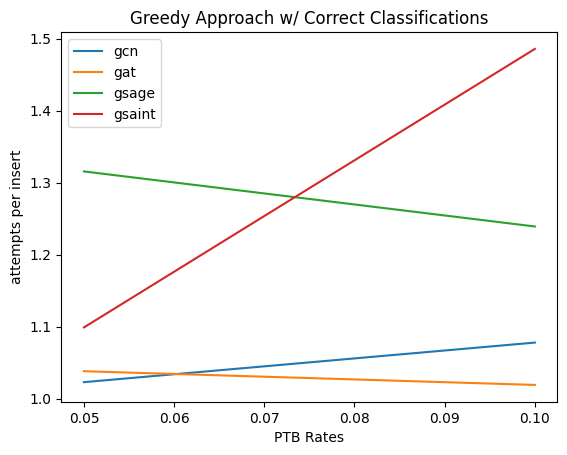

In [15]:
# Plotting
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]
plt.plot(ptb_rate, results_gcn, label="gcn")
plt.plot(ptb_rate, results_gat, label="gat")
plt.plot(ptb_rate, results_gsage, label="gsage")
plt.plot(ptb_rate, results_gsaint, label="gsaint")

plt.xlabel('PTB Rates')
plt.ylabel('attempts per insert')
plt.title('Greedy Approach w/ Correct Classifications')
plt.legend()

output_path = f"./data/correct-archs/greedy_archs_w_correct_classifications.png"
plt.savefig(output_path)

# Show plot
plt.show()

In [16]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/correct-archs/gcn/gcn_results.npy',
    f'./data-arrays/correct-archs/gat/gat_results.npy',
    f'./data-arrays/correct-archs/gsaint/gsaint_results.npy',
    f'./data-arrays/correct-archs/gsage/gsage_results.npy',
]

results = [
    np.array(results_gcn),
    np.array(results_gat),
    np.array(results_gsaint),
    np.array(results_gsage),
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)